In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


df = pd.read_csv('online_shoppers_intention.csv')


df = df.dropna()
print("Data successfully loaded and cleaned")

Data successfully loaded and cleaned


In [12]:
# --- DATA PREPARATION ---
# Target: 'Revenue' (Did the customer make a purchase? True/False)
y = df['Revenue']

# Features: All other columns regarding website behavior
X = df.drop('Revenue', axis=1)

# Convert categorical variables to numeric (One-Hot Encoding)
X_enc = pd.get_dummies(X, drop_first=True)

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_enc, y, test_size=0.2, random_state=42)
print("Data is succesvol gesplitst (Train/Test)")

Data is succesvol gesplitst (Train/Test)


In [ ]:

#DECISION TREE EXPERIMENTS

print("="*50, "\nDECISION TREE EXPERIMENTEN\n", "="*50)

# Exp 1: Initial Run (Shallow tree)
dt_1 = DecisionTreeClassifier(max_depth=1, random_state=42).fit(X_train, y_train)
print(f"Exp 1 (Baseline DT, max_depth=1) Accuracy: {accuracy_score(y_test, dt_1.predict(X_test)):.4f}")

# Exp 2: Slightly deeper tree
dt_2 = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)
print(f"Exp 2 (Deeper DT, max_depth=3) Accuracy: {accuracy_score(y_test, dt_2.predict(X_test)):.4f}")

# Exp 3: Even deeper tree (Starts learning data patterns)
dt_3 = DecisionTreeClassifier(max_depth=7, random_state=42).fit(X_train, y_train)
print(f"Exp 3 (Deeper DT, max_depth=7) Accuracy: {accuracy_score(y_test, dt_3.predict(X_test)):.4f}")

# Exp 4: Mathematical change 
dt_4 = DecisionTreeClassifier(max_depth=7, criterion='entropy', random_state=42).fit(X_train, y_train)
print(f"Exp 4 (Entropy Criterion, max_depth=7) Accuracy: {accuracy_score(y_test, dt_4.predict(X_test)):.4f}")

# Exp 5: Adding balance (Handling the imbalanced dataset)
dt_5 = DecisionTreeClassifier(max_depth=7, class_weight='balanced', random_state=42).fit(X_train, y_train)
print(f"Exp 5 (DT Class Weight Balanced) Accuracy: {accuracy_score(y_test, dt_5.predict(X_test)):.4f}\n")

DECISION TREE EXPERIMENTEN
Exp 1 (Baseline DT, max_depth=1) Accuracy: 0.8723
Exp 2 (Deeper DT, max_depth=3) Accuracy: 0.8885
Exp 3 (Deeper DT, max_depth=7) Accuracy: 0.8917
Exp 4 (Entropy Criterion, max_depth=7) Accuracy: 0.8938
Exp 5 (DT Class Weight Balanced) Accuracy: 0.8382



In [14]:

#RANDOM FOREST EXPERIMENTS (Ensemble Learning)

print("="*50, "\nRANDOM FOREST EXPERIMENTS\n", "="*50)

# Exp 6: Small forest (10 trees)
rf_6 = RandomForestClassifier(n_estimators=10, max_depth=7, random_state=42).fit(X_train, y_train)
print(f"Exp 6 (Random Forest, 10 trees) Accuracy: {accuracy_score(y_test, rf_6.predict(X_test)):.4f}")

# Exp 7: Standard forest (50 trees)
rf_7 = RandomForestClassifier(n_estimators=50, max_depth=7, random_state=42).fit(X_train, y_train)
print(f"Exp 7 (Random Forest, 50 trees) Accuracy: {accuracy_score(y_test, rf_7.predict(X_test)):.4f}")

# Exp 8: Larger forest (100 trees)
rf_8 = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42).fit(X_train, y_train)
print(f"Exp 8 (Random Forest, 100 trees) Accuracy: {accuracy_score(y_test, rf_8.predict(X_test)):.4f}")

# Exp 9: Deeper trees in the forest (max_depth=10)
rf_9 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42).fit(X_train, y_train)
print(f"Exp 9 (Deeper Random Forest, 100 trees) Accuracy: {accuracy_score(y_test, rf_9.predict(X_test)):.4f}\n")

RANDOM FOREST EXPERIMENTS
Exp 6 (Random Forest, 10 trees) Accuracy: 0.8889
Exp 7 (Random Forest, 50 trees) Accuracy: 0.8921
Exp 8 (Random Forest, 100 trees) Accuracy: 0.8946
Exp 9 (Deeper Random Forest, 100 trees) Accuracy: 0.8962



FINAL MODEL (EXP 10)
Exp 10 (Final Random Forest Model) Accuracy: 0.8812

--- Detailed Classification Report ---
              precision    recall  f1-score   support

       False       0.95      0.90      0.93      2055
        True       0.61      0.78      0.69       411

    accuracy                           0.88      2466
   macro avg       0.78      0.84      0.81      2466
weighted avg       0.90      0.88      0.89      2466



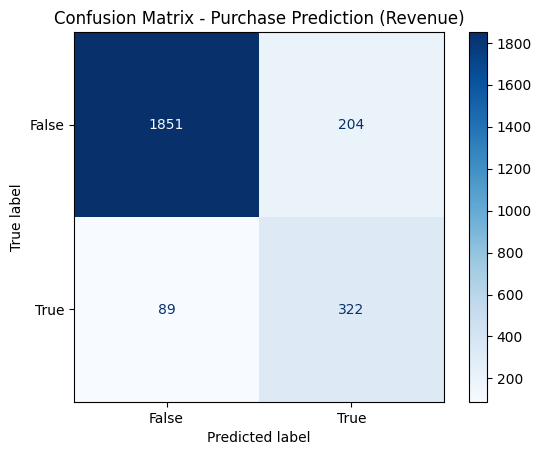

In [15]:
# PART 3: FINAL OPTIMIZED MODEL (EXP 10)

print("="*50, "\nFINAL MODEL (EXP 10)\n", "="*50)

# Exp 10: Final Model (Focus on finding the real buyers with 'balanced' class weights)
model_final = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)
model_final.fit(X_train, y_train)

# Make predictions
y_pred_final = model_final.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred_final)
print(f"Exp 10 (Final Random Forest Model) Accuracy: {final_accuracy:.4f}\n")

# --- REPORT & VISUALIZATION ---
print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred_final))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, cmap='Blues')
plt.title("Confusion Matrix - Purchase Prediction (Revenue)")
plt.show()